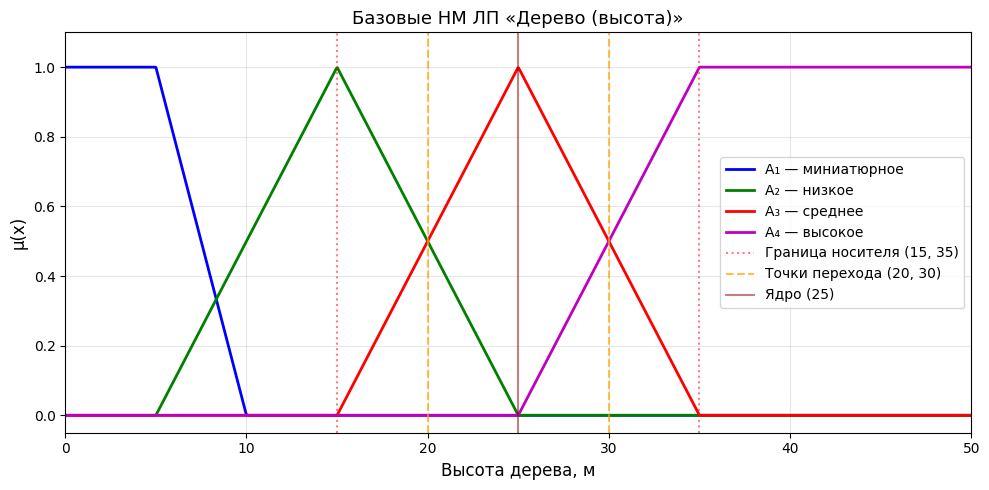

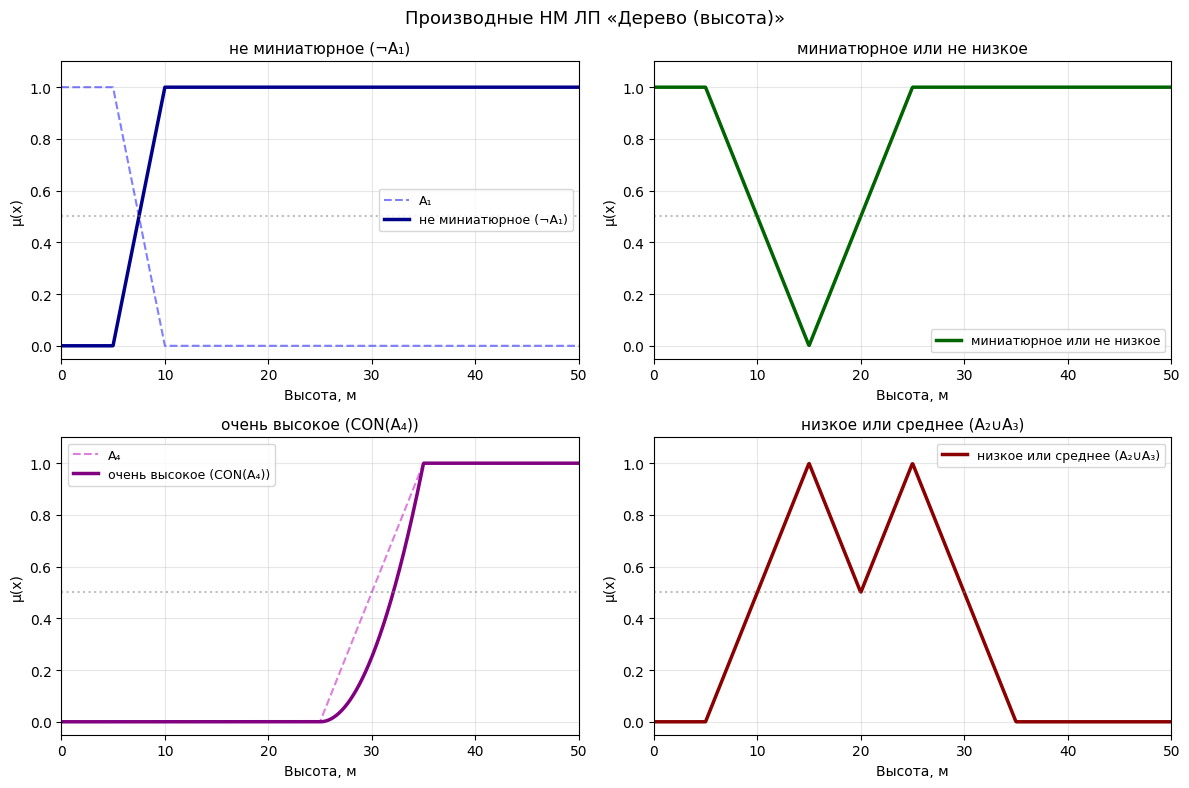

In [1]:
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(0, 50, 1000)

# ---- Базовые НМ ----
def mu_A1(x):  # миниатюрное
    return np.where(x <= 5, 1,
           np.where(x <= 10, (10 - x) / 5, 0))

def mu_A2(x):  # низкое
    return np.where(x <= 5, 0,
           np.where(x <= 15, (x - 5) / 10,
           np.where(x <= 25, (25 - x) / 10, 0)))

def mu_A3(x):  # среднее
    return np.where(x <= 15, 0,
           np.where(x <= 25, (x - 15) / 10,
           np.where(x <= 35, (35 - x) / 10, 0)))

def mu_A4(x):  # высокое
    return np.where(x <= 25, 0,
           np.where(x <= 35, (x - 25) / 10, 1))

# ---- Производные НМ ----
def mu_not_A1(x):             # не миниатюрное
    return 1 - mu_A1(x)

def mu_A1_or_not_A2(x):       # миниатюрное или не низкое
    return np.maximum(mu_A1(x), 1 - mu_A2(x))

def mu_very_A4(x):            # очень высокое
    return mu_A4(x) ** 2

def mu_A2_or_A3(x):           # низкое или среднее
    return np.maximum(mu_A2(x), mu_A3(x))

# ======== ГРАФИК 1: базовые НМ ========
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(x, mu_A1(x), 'b',   linewidth=2, label='A₁ — миниатюрное')
ax.plot(x, mu_A2(x), 'g',   linewidth=2, label='A₂ — низкое')
ax.plot(x, mu_A3(x), 'r',   linewidth=2, label='A₃ — среднее')
ax.plot(x, mu_A4(x), 'm',   linewidth=2, label='A₄ — высокое')

# Параметры НМ "среднее"
ax.axvline(x=15, color='r', linestyle=':', alpha=0.5, label='Граница носителя (15, 35)')
ax.axvline(x=35, color='r', linestyle=':', alpha=0.5)
ax.axvline(x=20, color='orange', linestyle='--', alpha=0.7, label='Точки перехода (20, 30)')
ax.axvline(x=30, color='orange', linestyle='--', alpha=0.7)
ax.axvline(x=25, color='darkred', linestyle='-', alpha=0.5, label='Ядро (25)')

ax.set_xlabel('Высота дерева, м', fontsize=12)
ax.set_ylabel('μ(x)', fontsize=12)
ax.set_title('Базовые НМ ЛП «Дерево (высота)»', fontsize=13)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_xlim(0, 50)
ax.set_ylim(-0.05, 1.1)
plt.tight_layout()
plt.savefig('base_fuzzy_sets.png', dpi=150)
plt.show()

# ======== ГРАФИК 2: производные НМ ========
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

plots = [
    (mu_not_A1,       'darkblue',  'не миниатюрное (¬A₁)',        mu_A1,  'b', 'A₁'),
    (mu_A1_or_not_A2, 'darkgreen', 'миниатюрное или не низкое',   None,   None, None),
    (mu_very_A4,      'purple',    'очень высокое (CON(A₄))',      mu_A4,  'm', 'A₄'),
    (mu_A2_or_A3,     'darkred',   'низкое или среднее (A₂∪A₃)',  None,   None, None),
]

for ax, (func, color, title, base_func, base_color, base_label) in zip(axes.flat, plots):
    if base_func is not None:
        ax.plot(x, base_func(x), base_color, linewidth=1.5,
                linestyle='--', alpha=0.5, label=base_label)
    ax.plot(x, func(x), color, linewidth=2.5, label=title)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('Высота, м')
    ax.set_ylabel('μ(x)')
    ax.set_xlim(0, 50)
    ax.set_ylim(-0.05, 1.1)
    ax.axhline(0.5, color='gray', linestyle=':', alpha=0.5)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.suptitle('Производные НМ ЛП «Дерево (высота)»', fontsize=13)
plt.tight_layout()
plt.savefig('derived_fuzzy_sets.png', dpi=150)
plt.show()